<a href="https://colab.research.google.com/github/aedwardscintron/NGG6050/blob/main/Code_for_QNC_Presentation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Shapiro-Wilk Tests for Sustained Spicule Protraction Time (Aldicarb Assay)

Sample standard deviation: 314.56
Standard deviation of synthetic normal distribution: 305.02


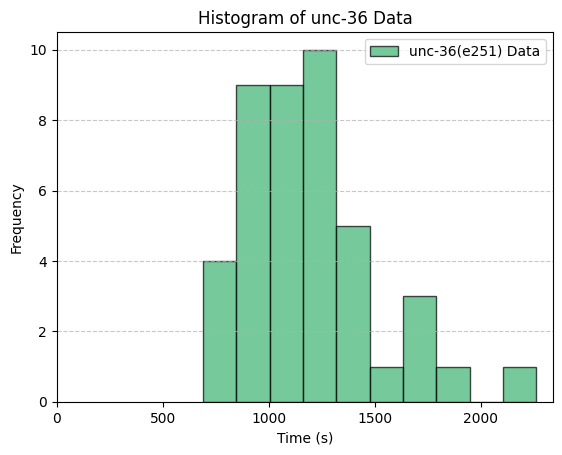

Shapiro-Wilk Test Results:
Statistic: 0.9237
P-value: 0.0071
The data does not appear to follow a normal distribution (reject H0).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Dataset for unc-36
data = [
    1078, 1150, 1185, 1303, 1361, 1453, 1680, 2262, 894, 982, 1068, 1205,
    1322, 1515, 1708, 810, 900, 1058, 1109, 1216, 1257, 1283, 1327, 1866,
    690, 807, 904, 970, 950, 969, 996, 1053, 1194, 1251, 1413, 1682, 690,
    936, 1020, 1059, 1184, 1231, 1070
]

# Calculate sample standard deviation
sample_std = np.std(data, ddof=1)
print(f"Sample standard deviation: {sample_std:.2f}")

# Create a synthetic normal distribution with same mean and size as data
mean = np.mean(data)
size = len(data)
normal_data = np.random.normal(loc=mean, scale=sample_std, size=size)

# Calculate the standard deviation of the synthetic normal distribution
#This step was included based on Dr. Gold's recommendation
normal_std = np.std(normal_data)
print(f"Standard deviation of synthetic normal distribution: {normal_std:.2f}")

# Plot the histogram
plt.hist(data, bins=10, color='mediumseagreen', edgecolor='black', alpha=0.7, label='unc-36(e251) Data')
plt.title('Histogram of unc-36 Data')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the x-axis to start from 0
plt.xlim(left=0)

plt.legend()
plt.show()

# Perform the Shapiro-Wilk test
stat, p_value = shapiro(data)

# Display the results
print("Shapiro-Wilk Test Results:")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The data appears to follow a normal distribution (fail to reject H0).")
else:
    print("The data does not appear to follow a normal distribution (reject H0).")


In [ ]:
#Log transformed data

Sample standard deviation of log-transformed data: 0.25
Standard deviation of synthetic normal distribution (log-transformed data): 0.25


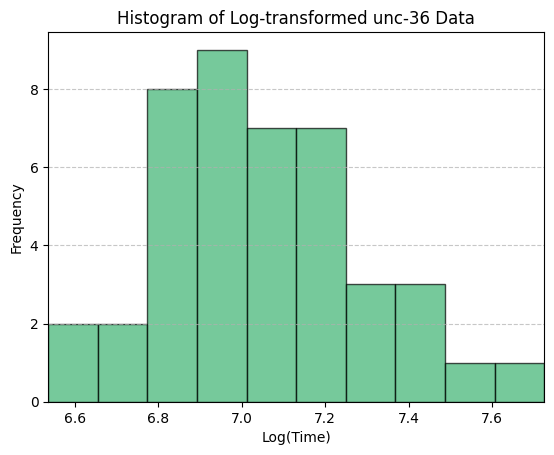

Shapiro-Wilk Test Results (Log-transformed data):
Statistic: 0.9827
P-value: 0.7550
The log-transformed data appears to follow a normal distribution (fail to reject H0).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Dataset for unc-36
data = [
    1078, 1150, 1185, 1303, 1361, 1453, 1680, 2262, 894, 982, 1068, 1205,
    1322, 1515, 1708, 810, 900, 1058, 1109, 1216, 1257, 1283, 1327, 1866,
    690, 807, 904, 970, 950, 969, 996, 1053, 1194, 1251, 1413, 1682, 690,
    936, 1020, 1059, 1184, 1231, 1070
]

# Log transform the data
log_data = np.log(data)

# Calculate sample standard deviation of the log-transformed data
sample_std_log = np.std(log_data, ddof=1)
print(f"Sample standard deviation of log-transformed data: {sample_std_log:.2f}")

# Create a synthetic normal distribution with same mean and std as log-transformed data
mean_log = np.mean(log_data)
size_log = len(log_data)
normal_data_log = np.random.normal(loc=mean_log, scale=sample_std_log, size=size_log)

# Calculate the standard deviation of the synthetic normal distribution for log-transformed data
normal_std_log = np.std(normal_data_log)
print(f"Standard deviation of synthetic normal distribution (log-transformed data): {normal_std_log:.2f}")

# Plot the histogram of the log-transformed data
plt.hist(log_data, bins=10, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title('Histogram of Log-transformed unc-36 Data')
plt.xlabel('Log(Time)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the x-axis to start from 0 for the log-transformed data
plt.xlim(left=min(log_data), right=max(log_data))

# No legend
# plt.legend()  # This line is removed

plt.show()

# Perform the Shapiro-Wilk test on the log-transformed data
stat_log, p_value_log = shapiro(log_data)

# Display the results
print("Shapiro-Wilk Test Results (Log-transformed data):")
print(f"Statistic: {stat_log:.4f}")
print(f"P-value: {p_value_log:.4f}")

# Interpretation of p-value for log-transformed data
if p_value_log > 0.05:
    print("The log-transformed data appears to follow a normal distribution (fail to reject H0).")
else:
    print("The log-transformed data does not appear to follow a normal distribution (reject H0).")


In [ ]:
#Assessing variance for log transformed data using Levene's test

In [ ]:
import numpy as np
from scipy.stats import levene

# Dataset for unc-36 - Experimental group
data1 = [
    58, 670, 818, 1115, 1140, 1524, 58, 793, 840, 914, 990, 1056, 1165, 1255,
    1295, 810, 823, 945, 967, 975, 904, 1138, 1260, 705, 1094, 1165, 1344,
    450, 546, 614, 970, 1028, 1112, 1156, 1398, 778, 925, 1104, 1162, 1264,
    1321, 1391
]

# Corresponding control group to unc-36
data2 = [
    471, 636, 665, 778, 516, 670, 820, 895, 948, 967, 566, 662, 680, 630, 740,
    854, 938, 1052, 1256, 1285, 470, 570, 540, 690, 715, 1150, 551, 598, 630,
    744, 828, 865, 923, 525, 601, 667, 692, 792, 877, 1212
]

# Log transform both datasets
log_data1 = np.log(data1)
log_data2 = np.log(data2)

# Perform Levene's test for equal variances on the log-transformed data
stat, p_value = levene(log_data1, log_data2)

# Display the results
print("Levene's Test Results (Log-transformed data):")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The variances between the experimental and control groups are equal (fail to reject H0).")
else:
    print("The variances between the experimental and control groups are not equal (reject H0).")


Levene's Test Results (Log-transformed data):
Statistic: 1.4820
P-value: 0.2270
The variances between the experimental and control groups are equal (fail to reject H0).


In [ ]:
#Shapiro-Wilk for unc-2 data

Sample standard deviation: 268.90
Standard deviation of synthetic normal distribution: 217.68


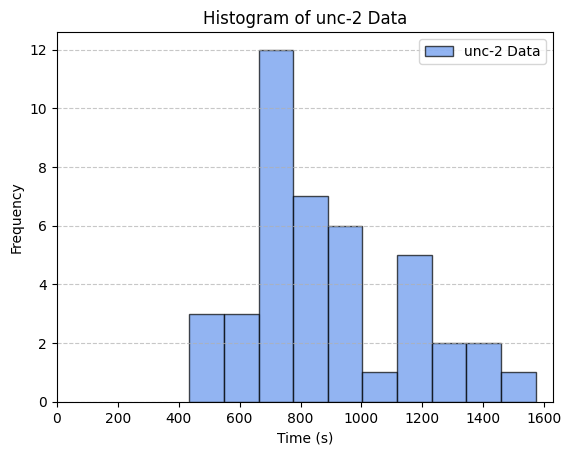

Shapiro-Wilk Test Results:
Statistic: 0.9383
P-value: 0.0249
The data does not appear to follow a normal distribution (reject H0).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Dataset for unc-2
data = [
    519, 590, 664, 762, 808, 861, 890, 925, 1052, 522, 614, 695, 756, 1276,
    605, 675, 716, 760, 801, 896, 1209, 1380, 1454, 435, 690, 760, 792, 976,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Calculate sample standard deviation
sample_std = np.std(data, ddof=1)
print(f"Sample standard deviation: {sample_std:.2f}")

# Create a synthetic normal distribution with same mean and size as data
mean = np.mean(data)
size = len(data)
normal_data = np.random.normal(loc=mean, scale=sample_std, size=size)

# Calculate the standard deviation of the synthetic normal distribution
normal_std = np.std(normal_data)
print(f"Standard deviation of synthetic normal distribution: {normal_std:.2f}")

# Plot the histogram
plt.hist(data, bins=10, color='cornflowerblue', edgecolor='black', alpha=0.7, label='unc-2 Data')
plt.title('Histogram of unc-2 Data')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the x-axis to start from 0
plt.xlim(left=0)

plt.legend()
plt.show()

# Perform the Shapiro-Wilk test
stat, p_value = shapiro(data)

# Display the results
print("Shapiro-Wilk Test Results:")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The data appears to follow a normal distribution (fail to reject H0).")
else:
    print("The data does not appear to follow a normal distribution (reject H0).")


In [ ]:
#Log transformed data

Sample standard deviation of log-transformed data: 0.30
Standard deviation of synthetic normal distribution (log-transformed data): 0.27


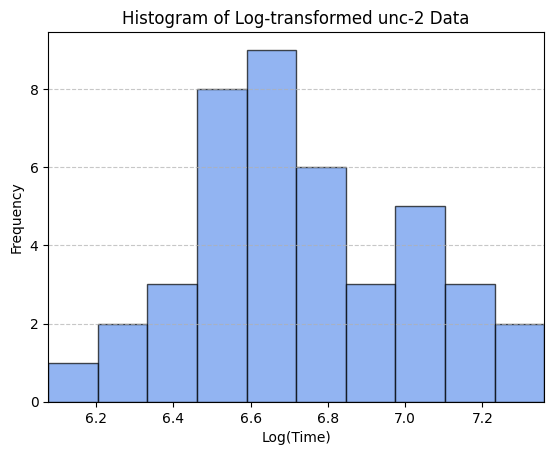

Shapiro-Wilk Test Results (Log-transformed data):
Statistic: 0.9800
P-value: 0.6631
The log-transformed data appears to follow a normal distribution (fail to reject H0).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Dataset for unc-2
data = [
    519, 590, 664, 762, 808, 861, 890, 925, 1052, 522, 614, 695, 756, 1276,
    605, 675, 716, 760, 801, 896, 1209, 1380, 1454, 435, 690, 760, 792, 976,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Log transform the data
log_data = np.log(data)

# Calculate sample standard deviation of the log-transformed data
sample_std_log = np.std(log_data, ddof=1)
print(f"Sample standard deviation of log-transformed data: {sample_std_log:.2f}")

# Create a synthetic normal distribution with the same mean and std as the log-transformed data
mean_log = np.mean(log_data)
size_log = len(log_data)
normal_data_log = np.random.normal(loc=mean_log, scale=sample_std_log, size=size_log)

# Calculate the standard deviation of the synthetic normal distribution for log-transformed data
normal_std_log = np.std(normal_data_log)
print(f"Standard deviation of synthetic normal distribution (log-transformed data): {normal_std_log:.2f}")

# Plot the histogram of the log-transformed data
plt.hist(log_data, bins=10, color='cornflowerblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Log-transformed unc-2 Data')
plt.xlabel('Log(Time)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set the x-axis to start from the minimum of the log-transformed data
plt.xlim(left=min(log_data), right=max(log_data))

plt.show()

# Perform the Shapiro-Wilk test on the log-transformed data
stat_log, p_value_log = shapiro(log_data)

# Display the results
print("Shapiro-Wilk Test Results (Log-transformed data):")
print(f"Statistic: {stat_log:.4f}")
print(f"P-value: {p_value_log:.4f}")

# Interpretation of p-value for log-transformed data
if p_value_log > 0.05:
    print("The log-transformed data appears to follow a normal distribution (fail to reject H0).")
else:
    print("The log-transformed data does not appear to follow a normal distribution (reject H0).")


In [ ]:
#Testing variance of log transformed data using Levene's test

In [ ]:
import numpy as np
from scipy.stats import levene

# Dataset for unc-2 (experimental group)
data1 = [
    519, 590, 664, 762, 808, 861, 890, 925, 1052, 522, 614, 695, 756, 1276,
    605, 675, 716, 760, 801, 896, 1209, 1380, 1454, 435, 690, 760, 792, 976,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Corresponding control group
data2 = [
    450, 481, 562, 606, 635, 686, 739, 483, 629, 809, 884, 901, 1069, 1109, 1210,
    401, 485, 642, 704, 733, 775, 810, 869, 510, 590, 788, 855, 925, 1007, 565,
    614, 684, 735, 854, 894, 1218, 696, 990, 1041, 1112, 1415
]

# Log transform both datasets
log_data1 = np.log(data1)
log_data2 = np.log(data2)

# Perform Levene's test on the log-transformed data
stat, p_value = levene(log_data1, log_data2)

# Display the results
print("Levene's Test Results (Log-transformed data1 vs. data2):")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The variances are equal (fail to reject H0).")
else:
    print("The variances are not equal (reject H0).")


Levene's Test Results (Log-transformed data1 vs. data2):
Statistic: 0.0684
P-value: 0.7943
The variances are equal (fail to reject H0).


In [ ]:
#Shapiro-Wilk for corresponding controls

In [ ]:
#Controls for unc-36 Shapiro-Wilk

import numpy as np
from scipy.stats import shapiro

# Corresponding control group for unc-36
data2 = [
    471, 636, 665, 778, 516, 670, 820, 895, 948, 967, 566, 662, 680, 630, 740,
    854, 938, 1052, 1256, 1285, 470, 570, 540, 690, 715, 1150, 551, 598, 630,
    744, 828, 865, 923, 525, 601, 667, 692, 792, 877, 1212
]

# Perform the Shapiro-Wilk test
statistic, p_value = shapiro(data)

# Output the results
print(f'Statistic: {statistic}, p-value: {p_value}')

# Interpret the result
alpha = 0.05
if p_value > alpha:
    print("The data follows a normal distribution (fail to reject H0).")
else:
      print("The data does not follow a normal distribution (reject H0).")

Statistic: 0.9382865951916687, p-value: 0.024903010049561854
The data does not follow a normal distribution (reject H0).


In [9]:
#Shapiro-wilk for log-transformed unc-36 controls

import numpy as np
from scipy.stats import shapiro

# Corresponding control group for unc-36
data2 = [
    471, 636, 665, 778, 516, 670, 820, 895, 948, 967, 566, 662, 680, 630, 740,
    854, 938, 1052, 1256, 1285, 470, 570, 540, 690, 715, 1150, 551, 598, 630,
    744, 828, 865, 923, 525, 601, 667, 692, 792, 877, 1212
]

# Log transform the data
log_data = np.log(data2)

# Perform the Shapiro-Wilk test on the log-transformed data
statistic, p_value = shapiro(log_data)

# Output the results
print(f'Statistic: {statistic}, p-value: {p_value}')

# Interpret the result
alpha = 0.05
if p_value > alpha:
    print("The data follows a normal distribution (fail to reject H0).")
else:
    print("The data does not follow a normal distribution (reject H0).")

Statistic: 0.9722334616616357, p-value: 0.42235234533124755
The data follows a normal distribution (fail to reject H0).


In [ ]:
#Controls for unc-2 Shapiro-Wilk

import numpy as np
from scipy.stats import shapiro

# Corresponding controls for unc-2
data2 = [
    450, 481, 562, 606, 635, 686, 739, 483, 629, 809, 884, 901, 1069, 1109, 1210,
    401, 485, 642, 704, 733, 775, 810, 869, 510, 590, 788, 855, 925, 1007, 565,
    614, 684, 735, 854, 894, 1218, 696, 990, 1041, 1112, 1415,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Perform the Shapiro-Wilk test
statistic, p_value = shapiro(data)

# Output the results
print(f'Statistic: {statistic}, p-value: {p_value}')

# Interpret the result
alpha = 0.05
if p_value > alpha:
    print("The data follows a normal distribution (fail to reject H0).")
else:
    print("The data does not follow a normal distribution (reject H0).")

Statistic: 0.9382865951916687, p-value: 0.024903010049561854
The data does not follow a normal distribution (reject H0).


In [ ]:
#Shapiro-wilk for log transformed data (controls for unc-2)

import numpy as np
from scipy.stats import shapiro

# Corresponding control group for unc-2
data2 = [
    450, 481, 562, 606, 635, 686, 739, 483, 629, 809, 884, 901, 1069, 1109, 1210,
    401, 485, 642, 704, 733, 775, 810, 869, 510, 590, 788, 855, 925, 1007, 565,
    614, 684, 735, 854, 894, 1218, 696, 990, 1041, 1112, 1415
]

# Log transform
log_data2 = np.log(data2)

# Perform the Shapiro-Wilk test on the log-transformed data
stat2, p_value2 = shapiro(log_data2)
# Display the results for data2 (control group)
print("\nShapiro-Wilk Test Results (Log-transformed data2):")
print(f"Statistic: {stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
if p_value2 > 0.05:
    print("The log-transformed data2 appears to follow a normal distribution (fail to reject H0).")
else:
    print("The log-transformed data2 does not appear to follow a normal distribution (reject H0).")



Shapiro-Wilk Test Results (Log-transformed data2):
Statistic: 0.9898
P-value: 0.9691
The log-transformed data2 appears to follow a normal distribution (fail to reject H0).


In [ ]:
#Power Analysis

In [ ]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower

# Define parameters for power analysis
cohen_d = 0.8  # Large effect size
alpha = 0.05  # Significance level (5%)
power = 0.8  # Desired power (80%)
ratio = 1  # Control: Experimental group size ratio (1:1)

# Initialize the power analysis object
analysis = TTestIndPower()

# Calculate the required sample size for a given power
sample_size = analysis.solve_power(effect_size=cohen_d, alpha=alpha, power=power, ratio=ratio)
print(f"Required sample size per group for power={power}: {np.ceil(sample_size)}")

# Calculate the power for sample size used in my study
n = 42  # Example: sample size per group
calculated_power = analysis.solve_power(effect_size=cohen_d, alpha=alpha, nobs1=n, ratio=ratio)
print(f"Calculated power for sample size={n}: {calculated_power:.4f}")

Required sample size per group for power=0.8: 26.0
Calculated power for sample size=42: 0.9518


In [ ]:
#Mann Whitney U Tests

Mann-Whitney U Test Statistic: 1260.5
P-value: 9.76443994959756e-05
The distributions of the two groups are different (reject H0).


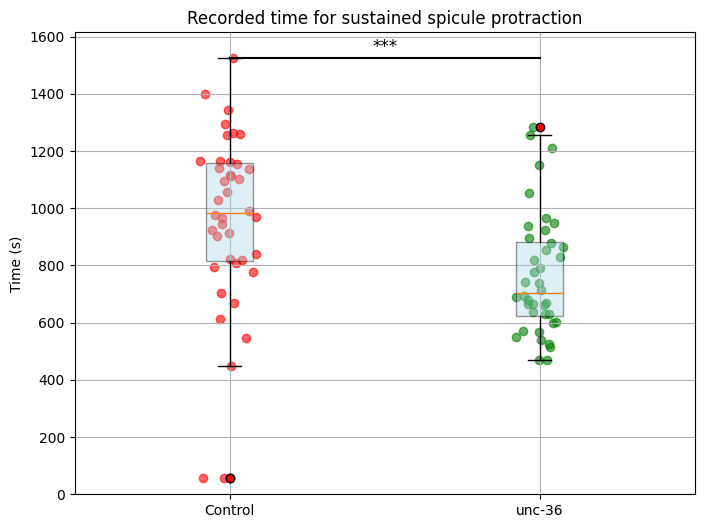

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Dataset for unc-36 - Experimental group
data1 = [
    58, 670, 818, 1115, 1140, 1524, 58, 793, 840, 914, 990, 1056, 1165, 1255,
    1295, 810, 823, 945, 967, 975, 904, 1138, 1260, 705, 1094, 1165, 1344,
    450, 546, 614, 970, 1028, 1112, 1156, 1398, 778, 925, 1104, 1162, 1264,
    1321, 1391
]

# Corresponding control group
data2 = [
    471, 636, 665, 778, 516, 670, 820, 895, 948, 967, 566, 662, 680, 630, 740,
    854, 938, 1052, 1256, 1285, 470, 570, 540, 690, 715, 1150, 551, 598, 630,
    744, 828, 865, 923, 525, 601, 667, 692, 792, 877, 1212
]

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(data1, data2)

# Display the results
print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation of p-value
if p_value > 0.05:
    print("The distributions of the two groups are similar (fail to reject H0).")
else:
    print("The distributions of the two groups are different (reject H0).")

# Combine data into a DataFrame for visualization
min_len = min(len(data1), len(data2))
data1 = data1[:min_len]  # Trim data1 to the minimum length
data2 = data2[:min_len]  # Trim data2 to the minimum length

# Combine the two groups into a DataFrame
dataset = np.array([data1, data2]).T  # Combining data1 and data2 as rows
df = pd.DataFrame(dataset, columns=['Control', 'unc-36'])

# Add jitter to x-axis positions for scatter points (to prevent overlap)
vals, names, xs = [], [], []
for i, col in enumerate(df.columns):
    vals.append(df[col].values)
    names.append(col)
    xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # Adds jitter to x-values

# Create a boxplot to visualize the distributions
plt.figure(figsize=(8, 6))
plt.boxplot(vals, labels=names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black', alpha=0.4),
            flierprops=dict(markerfacecolor='red', marker='o', markersize=6, markeredgewidth=1))

# Overlay individual data points with different colors
palette = ['r', 'g']  # Only two colors since we have two groups
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.6, color=c)

# Add significance bar and asterisks based on p-value
y_max = max(np.max(data1), np.max(data2))  # Maximum value for the y-axis
y_offset = 0.05 * y_max  # Offset above the maximum y-value for the significance bar

# Increase y-axis limit to make space for significance bar and asterisks
plt.ylim(0, y_max + 1.2 * y_offset)  # Extend the y-axis to allow space for significance bar

# Draw a line for the significance bar between the two groups, but lower the bar further
plt.plot([1, 2], [y_max + 0.015 * y_offset, y_max + 0.015 * y_offset], color='black', lw=1.5)  # Significance bar lower

# Add asterisks depending on the p-value, but move them lower
if p_value < 0.001:
    plt.text(1.5, y_max + 0.015 * y_offset + 0.005 * y_max, '***', ha='center', va='bottom', fontsize=12)
elif p_value < 0.01:
    plt.text(1.5, y_max + 0.015 * y_offset + 0.005 * y_max, '**', ha='center', va='bottom', fontsize=12)
elif p_value < 0.05:
    plt.text(1.5, y_max + 0.015 * y_offset + 0.005 * y_max, '*', ha='center', va='bottom', fontsize=12)

# Title and Labels
plt.title('Recorded time for sustained spicule protraction')
plt.ylabel('Time (s)')
plt.grid(True)
plt.show()


In [ ]:
#Independent t-test with log transformed data

Independent t-test Statistic: 1.3850
P-value: 0.1699
The means of the two groups are not significantly different (fail to reject H0).


<ipython-input-7-620659f14985>:73: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(i + 1, mean, color=color, marker='x', s=200, linewidth=3, edgecolor='black', alpha=1, label=f'Mean - {names[i]}: {mean:.2f}')


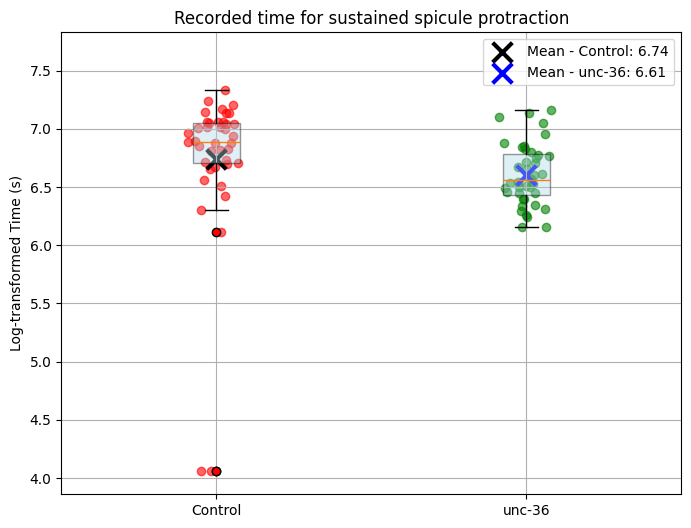

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Dataset for unc-36 - Experimental group
data1 = [
    58, 670, 818, 1115, 1140, 1524, 58, 793, 840, 914, 990, 1056, 1165, 1255,
    1295, 810, 823, 945, 967, 975, 904, 1138, 1260, 705, 1094, 1165, 1344,
    450, 546, 614, 970, 1028, 1112, 1156, 1398, 778, 925, 1104, 1162, 1264,
    1321, 1391
]

# Corresponding control group
data2 = [
    471, 636, 665, 778, 516, 670, 820, 895, 948, 967, 566, 662, 680, 630, 740,
    854, 938, 1052, 1256, 1285, 470, 570, 540, 690, 715, 1150, 551, 598, 630,
    744, 828, 865, 923, 525, 601, 667, 692, 792, 877, 1212
]

# Log transform both datasets
log_data1 = np.log(data1)
log_data2 = np.log(data2)

# Perform Independent t-test on the log-transformed data
stat, p_value = ttest_ind(log_data1, log_data2)

# Display the results
print(f"Independent t-test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The means of the two groups are not significantly different (fail to reject H0).")
else:
    print("The means of the two groups are significantly different (reject H0).")

# Combine data into a DataFrame for visualization
min_len = min(len(log_data1), len(log_data2))
log_data1 = log_data1[:min_len]  # Trim log_data1 to the minimum length
log_data2 = log_data2[:min_len]  # Trim log_data2 to the minimum length

# Combine the two groups into a DataFrame
dataset = np.array([log_data1, log_data2]).T  # Combining log_data1 and log_data2 as rows
df = pd.DataFrame(dataset, columns=['Control', 'unc-36'])

# Add jitter to x-axis positions for scatter points (to prevent overlap)
vals, names, xs = [], [], []
for i, col in enumerate(df.columns):
    vals.append(df[col].values)
    names.append(col)
    xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # Adds jitter to x-values

# Calculate means for both groups
means = [np.mean(log_data1), np.mean(log_data2)]

# Inverted colors for the means (Control black and unc-36 blue)
mean_colors = ['black', 'blue']

# Create a boxplot to visualize the distributions
plt.figure(figsize=(8, 6))
plt.boxplot(vals, labels=names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black', alpha=0.4),
            flierprops=dict(markerfacecolor='red', marker='o', markersize=6, markeredgewidth=1))

# Overlay individual data points with different colors
palette = ['r', 'g']  # Only two colors since we have two groups
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.6, color=c)

# Overlay means as "x" symbols with increased size and edge width
for i, (mean, color) in enumerate(zip(means, mean_colors)):
    plt.scatter(i + 1, mean, color=color, marker='x', s=200, linewidth=3, edgecolor='black', alpha=1, label=f'Mean - {names[i]}: {mean:.2f}')

# Adjust y-axis to ensure the box plots are more spread out
y_min = min(np.min(log_data1), np.min(log_data2))  # Minimum value for the y-axis
y_max = max(np.max(log_data1), np.max(log_data2))  # Maximum value for the y-axis
# Adjust y-axis limits to make the boxplots more spread out
plt.ylim(y_min - 0.2, y_max + 0.5)  # Adjusting the y-axis limits for better spacing

# Title and Labels
plt.title('Recorded time for sustained spicule protraction')
plt.ylabel('Log-transformed Time (s)')
plt.grid(True)

# Optional: Add a legend to identify the means with values
plt.legend()

plt.show()


Mann-Whitney U Test Statistic: 1034.5
P-value: 0.1150814973740841
The distributions of the two groups are similar (fail to reject H0).


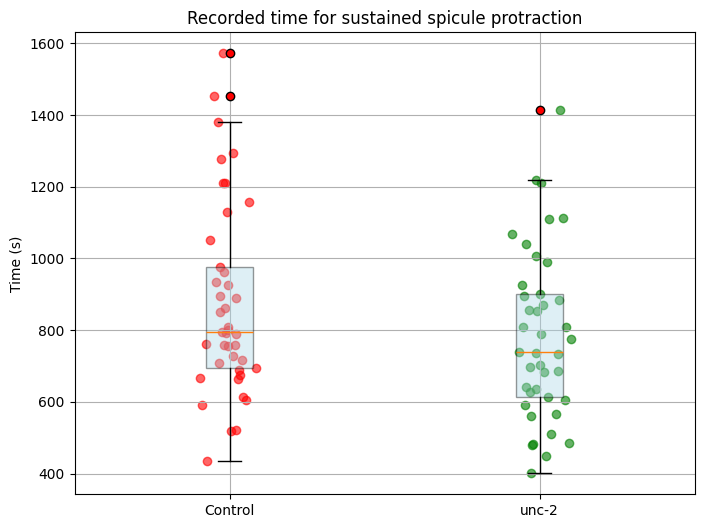

In [ ]:
#Mann Whitney U Test for unc-2 gene
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Dataset for unc-2
data1 = [
    519, 590, 664, 762, 808, 861, 890, 925, 1052, 522, 614, 695, 756, 1276,
    605, 675, 716, 760, 801, 896, 1209, 1380, 1454, 435, 690, 760, 792, 976,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Corresponding controls
data2 = [
    450, 481, 562, 606, 635, 686, 739, 483, 629, 809, 884, 901, 1069, 1109, 1210,
    401, 485, 642, 704, 733, 775, 810, 869, 510, 590, 788, 855, 925, 1007, 565,
    614, 684, 735, 854, 894, 1218, 696, 990, 1041, 1112, 1415
]

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(data1, data2)

# Display the results
print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation of p-value
if p_value > 0.05:
    print("The distributions of the two groups are similar (fail to reject H0).")
else:
    print("The distributions of the two groups are different (reject H0).")

# Combine data into a DataFrame for visualization
# Ensure data1 and data2 have the same length for creating a 2D array
min_len = min(len(data1), len(data2))
data1 = data1[:min_len]  # Trim data1 to the minimum length
data2 = data2[:min_len]  # Trim data2 to the minimum length

# Combine the two groups into a DataFrame
dataset = np.array([data1, data2]).T  # Combining data1 and data2 as rows
df = pd.DataFrame(dataset, columns=['Control', 'unc-2'])

# Add jitter to x-axis positions for scatter points (to prevent overlap)
vals, names, xs = [], [], []
for i, col in enumerate(df.columns):
    vals.append(df[col].values)
    names.append(col)
    xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # Adds jitter to x-values

# Create a boxplot to visualize the distributions
plt.figure(figsize=(8, 6))
plt.boxplot(vals, labels=names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black', alpha=0.4),  # Set alpha here for transparency
            flierprops=dict(markerfacecolor='red', marker='o', markersize=6, markeredgewidth=1))

# Overlay individual data points with different colors
palette = ['r', 'g']  # Only two colors since we have two groups
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.6, color=c)

# Title and Labels
plt.title('Recorded time for sustained spicule protraction')
plt.ylabel('Time (s)')
plt.grid(True)
plt.show()


In [ ]:
#Independent t-test for log transformed data

Independent t-test Statistic: 1.8108
P-value: 0.0739
The means of the two groups are not significantly different (fail to reject H0).


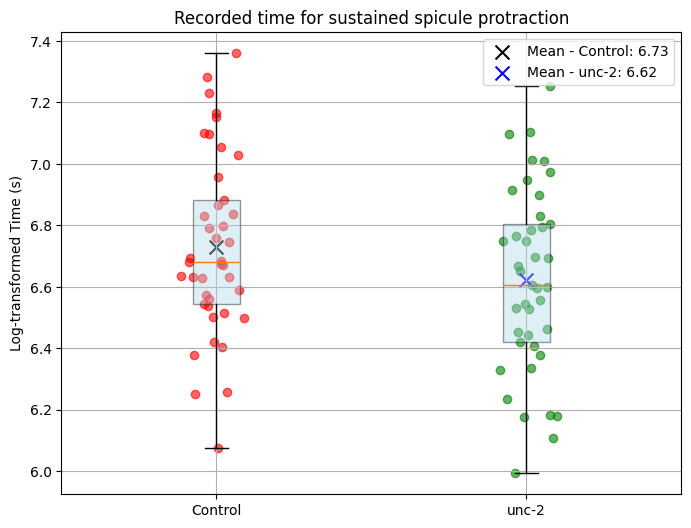

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Dataset for unc-2 (experimental group)
data1 = [
    519, 590, 664, 762, 808, 861, 890, 925, 1052, 522, 614, 695, 756, 1276,
    605, 675, 716, 760, 801, 896, 1209, 1380, 1454, 435, 690, 760, 792, 976,
    1130, 708, 790, 933, 1158, 1211, 1294, 1572, 666, 727, 796, 851, 961, 1204
]

# Corresponding control group
data2 = [
    450, 481, 562, 606, 635, 686, 739, 483, 629, 809, 884, 901, 1069, 1109, 1210,
    401, 485, 642, 704, 733, 775, 810, 869, 510, 590, 788, 855, 925, 1007, 565,
    614, 684, 735, 854, 894, 1218, 696, 990, 1041, 1112, 1415
]

# Log transform both datasets
log_data1 = np.log(data1)
log_data2 = np.log(data2)

# Perform Independent t-test on the log-transformed data
stat, p_value = ttest_ind(log_data1, log_data2)

# Display the results
print(f"Independent t-test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of p-value
if p_value > 0.05:
    print("The means of the two groups are not significantly different (fail to reject H0).")
else:
    print("The means of the two groups are significantly different (reject H0).")

# Combine data into a DataFrame for visualization
min_len = min(len(log_data1), len(log_data2))
log_data1 = log_data1[:min_len]  # Trim log_data1 to the minimum length
log_data2 = log_data2[:min_len]  # Trim log_data2 to the minimum length

# Combine the two groups into a DataFrame
dataset = np.array([log_data1, log_data2]).T  # Combining log_data1 and log_data2 as rows
df = pd.DataFrame(dataset, columns=['Control', 'unc-2'])

# Add jitter to x-axis positions for scatter points (to prevent overlap)
vals, names, xs = [], [], []
for i, col in enumerate(df.columns):
    vals.append(df[col].values)
    names.append(col)
    xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # Adds jitter to x-values

# Calculate means for both groups
means = [np.mean(log_data1), np.mean(log_data2)]

# Colors for the means (invert: Control black, unc-2 blue)
mean_colors = ['black', 'blue']

# Create a boxplot to visualize the distributions
plt.figure(figsize=(8, 6))
plt.boxplot(vals, labels=names, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black', alpha=0.4),  # Set alpha here for transparency
            flierprops=dict(markerfacecolor='red', marker='o', markersize=6, markeredgewidth=1))

# Overlay individual data points with different colors
palette = ['r', 'g']  # Only two colors since we have two groups
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.6, color=c)

# Overlay means as "x" symbols with different colors
for i, (mean, color) in enumerate(zip(means, mean_colors)):
    plt.scatter(i + 1, mean, color=color, marker='x', s=100, label=f'Mean - {names[i]}: {mean:.2f}')

# Title and Labels
plt.title('Recorded time for sustained spicule protraction')
plt.ylabel('Log-transformed Time (s)')
plt.grid(True)

# Optional: Add a legend to identify the means with values
plt.legend()

plt.show()


In [ ]:
#Shapiro-Wilk test for unc-36 DVB neuron morphology (neurite length)

Shapiro-Wilk Test Statistic: 0.8665589547511344
P-value: 0.09112768885963143
The distributions of the data are similar (fail to reject H0). The data are normally distributed.


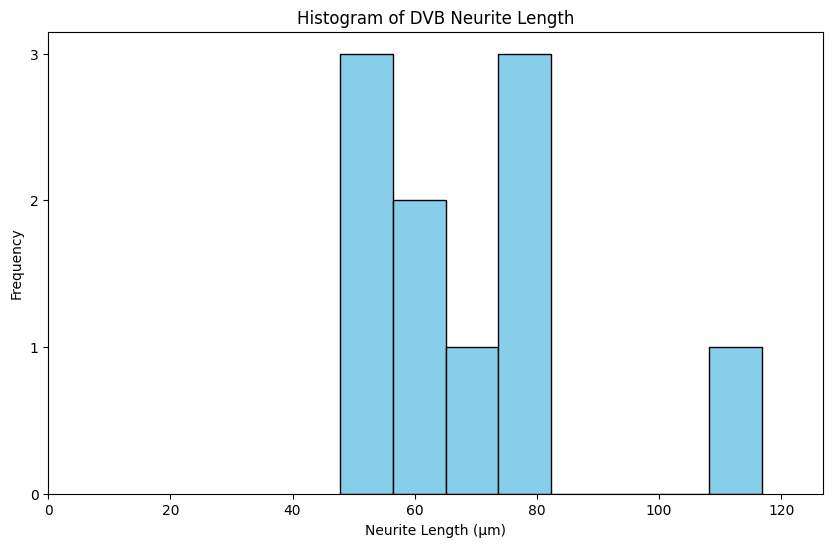

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro

# Data (experimental; unc-36)
data = [77.319, 49.272, 73.876, 47.796, 57.680, 81.45, 116.865, 60.616, 72.441, 48.958]

# Perform Shapiro-Wilk test for normality
stat, p_value = shapiro(data)

# Display Shapiro-Wilk test result
print(f"Shapiro-Wilk Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation of p-value
if p_value > 0.05:
    print("The distributions of the data are similar (fail to reject H0). The data are normally distributed.")
else:
    print("The distributions of the data are different (reject H0). The data are not normally distributed.")

# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=8, color='skyblue', edgecolor='black', density=False)

# Customize the plot
plt.title('Histogram of DVB Neurite Length')
plt.xlabel('Neurite Length (μm)')
plt.ylabel('Frequency')

# Set the x-axis to start from 0
plt.xlim(0, max(data) + 10)

# Set y-axis to whole numbers (integer scale)
plt.yticks(np.arange(0, max(np.histogram(data, bins=8)[0]) + 1, 1))

# Display the plot
plt.show()


Shapiro-Wilk Test Statistic: 0.9310703825439671
P-value: 0.4585028758039912
The distributions of the data are similar (fail to reject H0). The data are normally distributed.


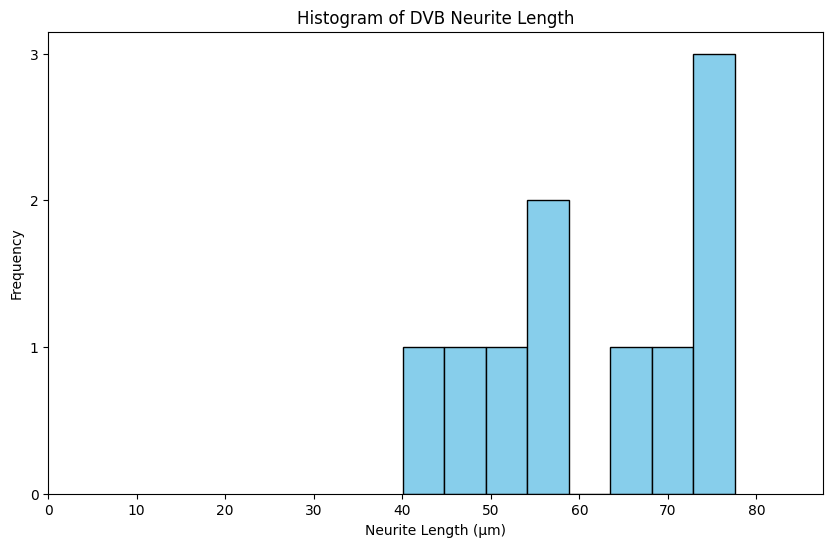

In [ ]:
#Shapiro-Wilk and data visualization for corresponding controls
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro

# Data (control)
data = [40.06, 56.555, 73.655, 74.487, 52.674, 48.132, 77.544, 65.429, 71.561, 54.510]

# Perform Shapiro-Wilk test for normality
stat, p_value = shapiro(data)

# Display Shapiro-Wilk test result
print(f"Shapiro-Wilk Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation of p-value
if p_value > 0.05:
    print("The distributions of the data are similar (fail to reject H0). The data are normally distributed.")
else:
    print("The distributions of the data are different (reject H0). The data are not normally distributed.")

# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=8, color='skyblue', edgecolor='black', density=False)  # density=False for frequency

# Customize the plot
plt.title('Histogram of DVB Neurite Length')
plt.xlabel('Neurite Length (μm)')
plt.ylabel('Frequency')

# Set the x-axis to start from 0
plt.xlim(0, max(data) + 10)  # Set x-axis to start at 0 and extend beyond the max data value

# Set y-axis to whole numbers (integer scale)
plt.yticks(np.arange(0, max(np.histogram(data, bins=8)[0]) + 1, 1))

# Display the plot
plt.show()

In [ ]:
#Levene's Test for DVB neurite length

In [ ]:
from scipy.stats import levene

# Experimental and control data
experimental_data = [77.319, 49.272, 73.876, 47.796, 57.680, 81.45, 116.865, 60.616, 72.441, 48.958]
control_data = [40.06, 56.555, 73.655, 74.487, 52.674, 48.132, 77.544, 65.429, 71.561, 54.510]

# Perform Levene's test for equal variance
stat, p_value = levene(experimental_data, control_data)

# Print the results
print("Levene's Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value > 0.05:
    print("Fail to reject the null hypothesis: The two groups have equal variance (homogeneous variances).")
else:
    print("Reject the null hypothesis: The two groups do not have equal variance (heterogeneous variances).")

Levene's Test Statistic: 1.096877349132121
p-value: 0.3088128831076017
Fail to reject the null hypothesis: The two groups have equal variance (homogeneous variances).


In [ ]:
#Independent T-test given normal distribution and equal variance

t-statistic: 0.919
p-value: 0.370
Fail to reject the null hypothesis: The means of the two groups are not significantly different.

Descriptive Statistics:
Experimental Group:
  Mean: 68.627
  Median: 66.529
  Std Dev: 19.971

Control Group:
  Mean: 61.461
  Median: 60.992
  Std Dev: 12.166



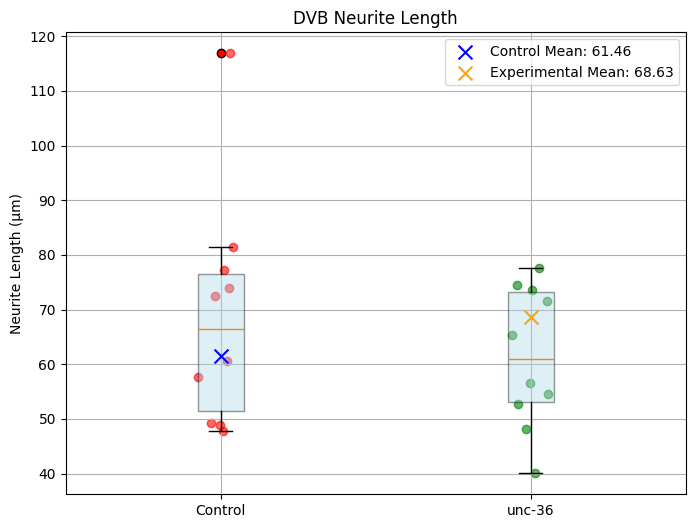

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Function to perform an independent t-test
def perform_t_test(experimental_data, control_data, equal_var=True):
    t_stat, p_value = ttest_ind(experimental_data, control_data, equal_var=equal_var)
    return t_stat, p_value

# Function to interpret the results of the t-test
def interpret_results(p_value):
    if p_value > 0.05:
        return "Fail to reject the null hypothesis: The means of the two groups are not significantly different."
    else:
        return "Reject the null hypothesis: The means of the two groups are significantly different."

# Function to compute descriptive statistics
def get_descriptive_stats(experimental_data, control_data):
    stats = {
        'Experimental': {
            'Mean': np.mean(experimental_data),
            'Median': np.median(experimental_data),
            'Std': np.std(experimental_data)
        },
        'Control': {
            'Mean': np.mean(control_data),
            'Median': np.median(control_data),
            'Std': np.std(control_data)
        }
    }
    return stats

# Function to create boxplot and overlay jittered scatter points and means
def visualize_data(experimental_data, control_data):
    # Combine the two groups into a DataFrame for easier manipulation
    dataset = np.array([experimental_data, control_data]).T  # Combine experimental and control as rows
    df = pd.DataFrame(dataset, columns=['Control', 'unc-36'])

    # Add jitter to x-axis positions for scatter points (to prevent overlap)
    vals, names, xs = [], [], []
    for i, col in enumerate(df.columns):
        vals.append(df[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # Adds jitter to x-values

    # Create a boxplot to visualize the distributions
    plt.figure(figsize=(8, 6))
    plt.boxplot(vals, labels=names, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black', alpha=0.4),  # Set transparency for boxes
                flierprops=dict(markerfacecolor='red', marker='o', markersize=6, markeredgewidth=1))  # Outliers

    # Overlay individual data points with different colors (data points remain circular)
    palette = ['r', 'g']  # Red for Experimental and Green for Control
    for x, val, c in zip(xs, vals, palette):
        plt.scatter(x, val, alpha=0.6, color=c, marker='o')  # Data points as circles

    # Calculate the means of each group
    mean_exp = np.mean(experimental_data)
    mean_ctrl = np.mean(control_data)

    # Overlay the means on the boxplot (mean markers are 'x')
    plt.scatter([1], [mean_ctrl], color='blue', label=f'Control Mean: {mean_ctrl:.2f}', zorder=3, marker='x', s=100)
    plt.scatter([2], [mean_exp], color='orange', label=f'Experimental Mean: {mean_exp:.2f}', zorder=3, marker='x', s=100)

    # Add title, labels, legend, and grid
    plt.title('DVB Neurite Length')
    plt.ylabel('Neurite Length (μm)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main analysis function
def main():
    # Experimental and control data
    experimental_data = [77.319, 49.272, 73.876, 47.796, 57.680, 81.45, 116.865, 60.616, 72.441, 48.958]
    control_data = [40.06, 56.555, 73.655, 74.487, 52.674, 48.132, 77.544, 65.429, 71.561, 54.510]

    # Perform the t-test
    t_stat, p_value = perform_t_test(experimental_data, control_data)

    # Print the results
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.3f}")

    # Interpret the results
    interpretation = interpret_results(p_value)
    print(interpretation)

    # Compute and print descriptive statistics for both groups
    stats = get_descriptive_stats(experimental_data, control_data)
    print("\nDescriptive Statistics:")
    for group, group_stats in stats.items():
        print(f"{group} Group:")
        print(f"  Mean: {group_stats['Mean']:.3f}")
        print(f"  Median: {group_stats['Median']:.3f}")
        print(f"  Std Dev: {group_stats['Std']:.3f}\n")

    # Visualize the data with boxplot and means
    visualize_data(experimental_data, control_data)

# Run the main function to perform the analysis
if __name__ == "__main__":
    main()


In [ ]:
#Simulated data for non-distributed data summary figure (Aldicarb data)

Kruskal-Wallis Test Statistic: 310.1307308183236
P-value: 1.12e-60
There is a significant difference between the groups (reject H0).

Dunn's Test Results (Control vs Experimental Groups with Bonferroni correction):
Gene 1 is not significantly different from the control (p-value = 1.00e+00)
Gene 2 is not significantly different from the control (p-value = 1.00e+00)
Gene 3 is significantly different from the control (p-value = 1.64e-10)
Gene 4 is not significantly different from the control (p-value = 1.00e+00)
Gene 5 is significantly different from the control (p-value = 7.08e-11)
Gene 6 is significantly different from the control (p-value = 5.27e-04)
Gene 7 is significantly different from the control (p-value = 1.23e-15)
Gene 8 is not significantly different from the control (p-value = 1.00e+00)
Gene 9 is significantly different from the control (p-value = 5.27e-04)
Gene 10 is significantly different from the control (p-value = 4.54e-04)


<ipython-input-97-c06bf7fabba0>:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Scaled Value', data=data_to_plot, palette='muted', showfliers=False, width=0.5)


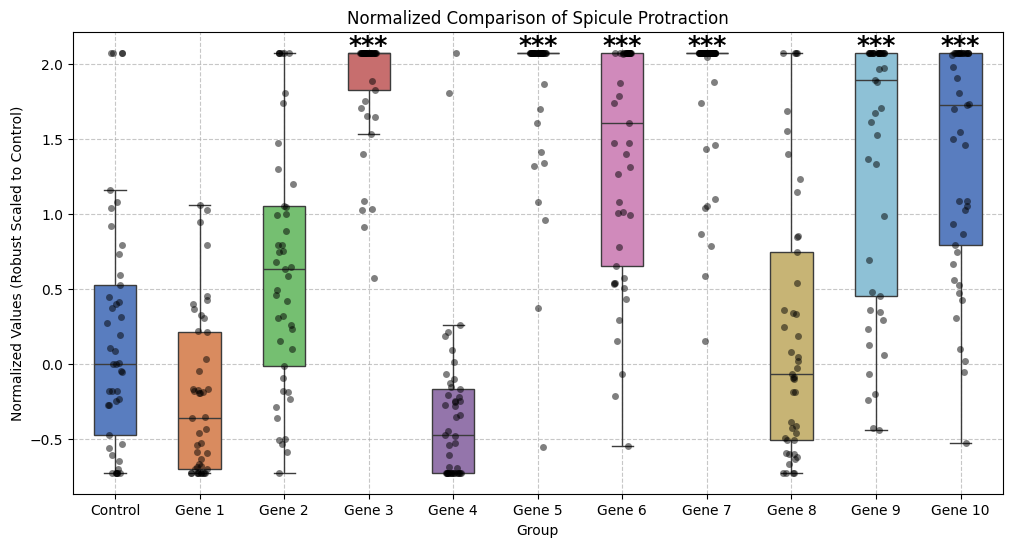

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp

# Set random seed for reproducibility
np.random.seed(42)

# Generate non-normally distributed data (skewed data using log-normal distribution)
mean_ctrl = 600  # Mean for control group
std_dev_ctrl = 130  # Standard deviation for control group
shape_ctrl = 0.5  # Shape parameter for log-normal distribution to make it skewed

# Generate control group data (45 samples)
control_data = np.random.lognormal(mean=np.log(mean_ctrl), sigma=shape_ctrl, size=45)
control_data_clipped = np.clip(control_data, 300, 1200)  # Clip data to the range [300, 1200]

# Generate 10 experimental groups with different means and the same shape parameter
experimental_groups = []
means_exp = [700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150]  # Different means for each group
shape_exp = 0.5  # Same shape parameter for all experimental groups to maintain skewness

# Manually adjust the medians of some groups to make them more different from the control
modified_means = means_exp.copy()

# Increase the median of groups 3, 5, and 7 (index 2, 4, 6) to make them larger than the control
modified_means[2] = 1600  # Group 3: Increase median
modified_means[4] = 1800  # Group 5: Increase median
modified_means[6] = 2000  # Group 7: Increase median

# Decrease the median of groups 1, 4, and 8 (index 0, 3, 7) to make them smaller than the control
modified_means[0] = 400  # Group 1: Decrease median
modified_means[3] = 350  # Group 4: Decrease median
modified_means[7] = 500  # Group 8: Decrease median

# Create 10 experimental groups based on modified means
for mean in modified_means:
    group_size = 45  # Default size for most groups
    group = np.random.lognormal(mean=np.log(mean), sigma=shape_exp, size=group_size)
    group_clipped = np.clip(group, 300, 1200)  # Clip data to the range [300, 1200]
    experimental_groups.append(group_clipped)

# Increase the size of Gene 7 (index 6) to 75 samples
gene_7_size = 75
gene_7_group = np.random.lognormal(mean=np.log(modified_means[6]), sigma=shape_exp, size=gene_7_size)
gene_7_group_clipped = np.clip(gene_7_group, 300, 1200)  # Clip data to the range [300, 1200]
experimental_groups[6] = gene_7_group_clipped  # Replace the original gene 7 group with the larger one

# Perform Kruskal-Wallis test (non-parametric test) on all groups (control + 10 experimental groups)
kruskal_result = kruskal(control_data_clipped, *experimental_groups)

# Display the results of the Kruskal-Wallis test
print(f"Kruskal-Wallis Test Statistic: {kruskal_result.statistic}")
print(f"P-value: {kruskal_result.pvalue:.2e}")  # Scientific notation for Kruskal-Wallis p-value

# Interpretation of the p-value for Kruskal-Wallis test
if kruskal_result.pvalue < 0.05:
    print("There is a significant difference between the groups (reject H0).")
else:
    print("There is no significant difference between the groups (fail to reject H0).")

# Perform Dunn's post-hoc test for pairwise comparisons after Kruskal-Wallis test
dunn_results = sp.posthoc_dunn([control_data_clipped] + experimental_groups, p_adjust='bonferroni')

# Since we only care about control vs experimental groups, we will focus on the control row/column
# Filter the pairwise comparisons involving the control group
control_dunn_results = dunn_results.iloc[0, 1:]  # Row 0 corresponds to control group

# Apply Bonferroni correction to only the control vs experimental comparisons
# Since 'control_dunn_results' contains the p-values between the control and each experimental group,
# we apply the Bonferroni correction here as needed:
control_dunn_results_corrected = multipletests(control_dunn_results.values, method='bonferroni')[1]

# Display corrected Dunn's test results
print("\nDunn's Test Results (Control vs Experimental Groups with Bonferroni correction):")
for i, p_value in enumerate(control_dunn_results_corrected):
    group = f"Gene {i+1}"
    if p_value < 0.05:
        print(f"{group} is significantly different from the control (p-value = {p_value:.2e})")  # Scientific notation for p-values
    else:
        print(f"{group} is not significantly different from the control (p-value = {p_value:.2e})")  # Scientific notation for p-values

# Robust Scaling: Compute the median and IQR of the control group
control_median = np.median(control_data_clipped)
control_IQR = np.percentile(control_data_clipped, 75) - np.percentile(control_data_clipped, 25)

# Apply robust scaling to both experimental groups and control data
scaled_control = (control_data_clipped - control_median) / control_IQR
scaled_groups = [(group - control_median) / control_IQR for group in experimental_groups]

# Create a DataFrame for plotting with seaborn (combining all scaled data)
data_to_plot = pd.DataFrame({
    'Group': ['Control'] * len(scaled_control) + [f'Gene {i+1}' for i in range(10) for _ in range(len(scaled_groups[i]))],
    'Scaled Value': np.concatenate([scaled_control, *scaled_groups])
})

# Function to determine the number of asterisks based on p-value
def get_asterisks(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

# Plot using a boxplot and strip plot for comparison
plt.figure(figsize=(12, 6))

# Create boxplot
sns.boxplot(x='Group', y='Scaled Value', data=data_to_plot, palette='muted', showfliers=False, width=0.5)

# Create stripplot to show individual data points
sns.stripplot(x='Group', y='Scaled Value', data=data_to_plot, jitter=True, color='black', alpha=0.5)

# Add title and labels
plt.title('Normalized Comparison of Spicule Protraction')
plt.ylabel('Normalized Values (Robust Scaled to Control)')
plt.xlabel('Group')

# Add asterisks for significance with black color and bold
for i, p_value in enumerate(control_dunn_results_corrected):
    asterisks = get_asterisks(p_value)  # Get the appropriate number of asterisks based on p-value
    if asterisks:
        group = f'Gene {i+1}'
        y_max = np.max(data_to_plot[data_to_plot['Group'] == group]['Scaled Value'])
        # Lower the position of the asterisks
        plt.text(i + 1, y_max - 0.03, asterisks, ha='center', va='bottom', color='black', fontsize=18, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
#Simulated data for Normalized Data summary figure (could be used to represent DVB neurite length or log-transformed aldicarb assay data)

One-way ANOVA Test Statistic: 3.6770167635978193
P-value: 8.47e-05
There is a significant difference between the groups (reject H0).

Tukey's HSD Test Results (Control vs Experimental Groups):
Control vs Gene 1: p-value = 1.00e+00 
Control vs Gene 10: p-value = 8.00e-04 *
Control vs Gene 2: p-value = 9.98e-01 
Control vs Gene 3: p-value = 9.33e-01 
Control vs Gene 4: p-value = 9.15e-01 
Control vs Gene 5: p-value = 5.77e-01 
Control vs Gene 6: p-value = 9.86e-02 
Control vs Gene 7: p-value = 2.45e-01 
Control vs Gene 8: p-value = 9.17e-01 
Control vs Gene 9: p-value = 3.02e-02 *


<ipython-input-98-a8441e786745>:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Z-Score Value', data=data_to_plot, palette='muted', showfliers=False, width=0.5)


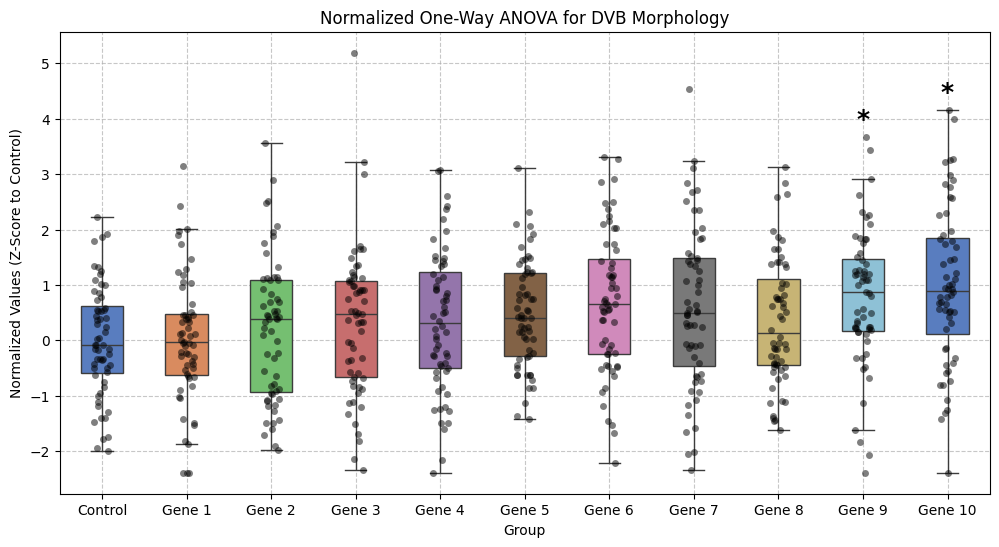

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set random seed for reproducibility
np.random.seed(42)

# Generate normally distributed data
mean_ctrl = 600  # Mean for control group
std_dev_ctrl = 130  # Standard deviation for control group

# Generate control group data (60 samples)
control_data = np.random.normal(loc=mean_ctrl, scale=std_dev_ctrl, size=60)
control_data_clipped = np.clip(control_data, 300, 1200)  # Clip data to the range [300, 1200]

# Generate 10 experimental groups with means closer to the control mean
experimental_groups = []
# Set means for experimental groups to be closer to the control mean
means_exp = [580, 590, 610, 620, 630, 640, 650, 660, 670, 680]  # Closer means
std_dev_exp = 150  # Increased standard deviation for more overlap

# Create 10 experimental groups based on adjusted means
for mean in means_exp:
    group = np.random.normal(loc=mean, scale=std_dev_exp, size=60)  # Moderate sample size
    group_clipped = np.clip(group, 300, 1200)  # Clip data to the range [300, 1200]
    experimental_groups.append(group_clipped)

# Perform one-way ANOVA (parametric test) on all groups (control + 10 experimental groups)
anova_result = f_oneway(control_data_clipped, *experimental_groups)

# Display the results of the ANOVA
print(f"One-way ANOVA Test Statistic: {anova_result.statistic}")
print(f"P-value: {anova_result.pvalue:.2e}")  # Scientific notation for ANOVA p-value

# Interpretation of the p-value for ANOVA
if anova_result.pvalue < 0.05:
    print("There is a significant difference between the groups (reject H0).")
else:
    print("There is no significant difference between the groups (fail to reject H0).")

# Perform Tukey's HSD post-hoc test for pairwise comparisons after ANOVA
# Combine all data into one array for Tukey's HSD
all_data = np.concatenate([control_data_clipped] + experimental_groups)
groups = ['Control'] * len(control_data_clipped) + [f'Gene {i+1}' for i in range(10) for _ in range(len(experimental_groups[i]))]

# Perform Tukey's HSD
tukey_result = pairwise_tukeyhsd(all_data, groups, alpha=0.05)

# Display Tukey's results for only control vs experimental groups
print("\nTukey's HSD Test Results (Control vs Experimental Groups):")
# Filter results for only control vs experimental comparisons
tukey_summary = tukey_result.summary()
control_comparisons = [row for row in tukey_summary.data if row[0] == 'Control' or row[1] == 'Control']

# Print filtered Tukey results with scientific notation for p-values
for comparison in control_comparisons:
    group1, group2, meandiff, p_value, lower, upper, reject = comparison
    asterisks = '*' if p_value < 0.05 else ''
    # Use scientific notation for p-values
    print(f"{group1} vs {group2}: p-value = {p_value:.2e} {asterisks}")

# Z-score Normalization to control group
control_mean = np.mean(control_data_clipped)
control_std = np.std(control_data_clipped)

# Apply Z-score normalization to both experimental groups and control data
z_score_control = (control_data_clipped - control_mean) / control_std
z_score_groups = [(group - control_mean) / control_std for group in experimental_groups]

# Create a DataFrame for plotting with seaborn
data_to_plot = pd.DataFrame({
    'Group': ['Control'] * len(z_score_control) + [f'Gene {i+1}' for i in range(10) for _ in range(len(z_score_groups[i]))],
    'Z-Score Value': np.concatenate([z_score_control, *z_score_groups])
})

# Plot using a boxplot and strip plot for comparison
plt.figure(figsize=(12, 6))

# Create boxplot
sns.boxplot(x='Group', y='Z-Score Value', data=data_to_plot, palette='muted', showfliers=False, width=0.5)

# Create stripplot to show individual data points
sns.stripplot(x='Group', y='Z-Score Value', data=data_to_plot, jitter=True, color='black', alpha=0.5)

# Add title and labels
plt.title('Normalized One-Way ANOVA for DVB Morphology')
plt.ylabel('Normalized Values (Z-Score to Control)')
plt.xlabel('Group')

# Add asterisks for significance
for comparison in control_comparisons:
    group1, group2, meandiff, p_value, lower, upper, reject = comparison
    asterisks = '*' if p_value < 0.05 else ''
    if asterisks:
        group = group2 if group1 == 'Control' else group1  # The experimental group
        y_max = np.max(data_to_plot[data_to_plot['Group'] == group]['Z-Score Value'])
        plt.text(data_to_plot['Group'].unique().tolist().index(group), y_max + 0.1, asterisks, ha='center', va='bottom', color='black', fontsize=18, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()